In [3]:
# --- Import library ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import LearningRateScheduler

In [4]:
# --- Load dataset MNIST (sudah termasuk train dan test split) ---
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


In [5]:
# --- Preprocessing ---

# Reshape untuk CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Normalisasi pixel values ke range [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encoding untuk labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"\nSetelah pre-processing:")
print(f"x_train shape: {x_train.shape}")
print(f"y_train_cat shape: {y_train_cat.shape}")


Setelah pre-processing:
x_train shape: (60000, 28, 28, 1)
y_train_cat shape: (60000, 10)


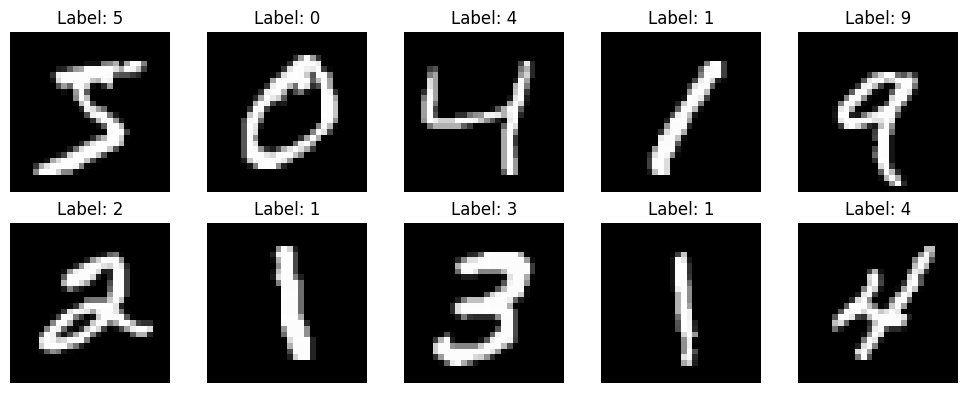

In [6]:
# Visualisasi beberapa contoh gambar
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')
plt.tight_layout()

In [9]:
# --- Data Augmentation ---
datagen = ImageDataGenerator(
    rotation_range=10,        # Rotasi random hingga 10 derajat
    width_shift_range=0.1,    # Shift horizontal hingga 10%
    height_shift_range=0.1,   # Shift vertikal hingga 10%
    zoom_range=0.1,           # Zoom in/out hingga 10%
    shear_range=0.1,          # Shear transformation
    fill_mode='nearest'       # Cara mengisi pixel yang kosong
) 

# Fit generator pada training data
datagen.fit(x_train)

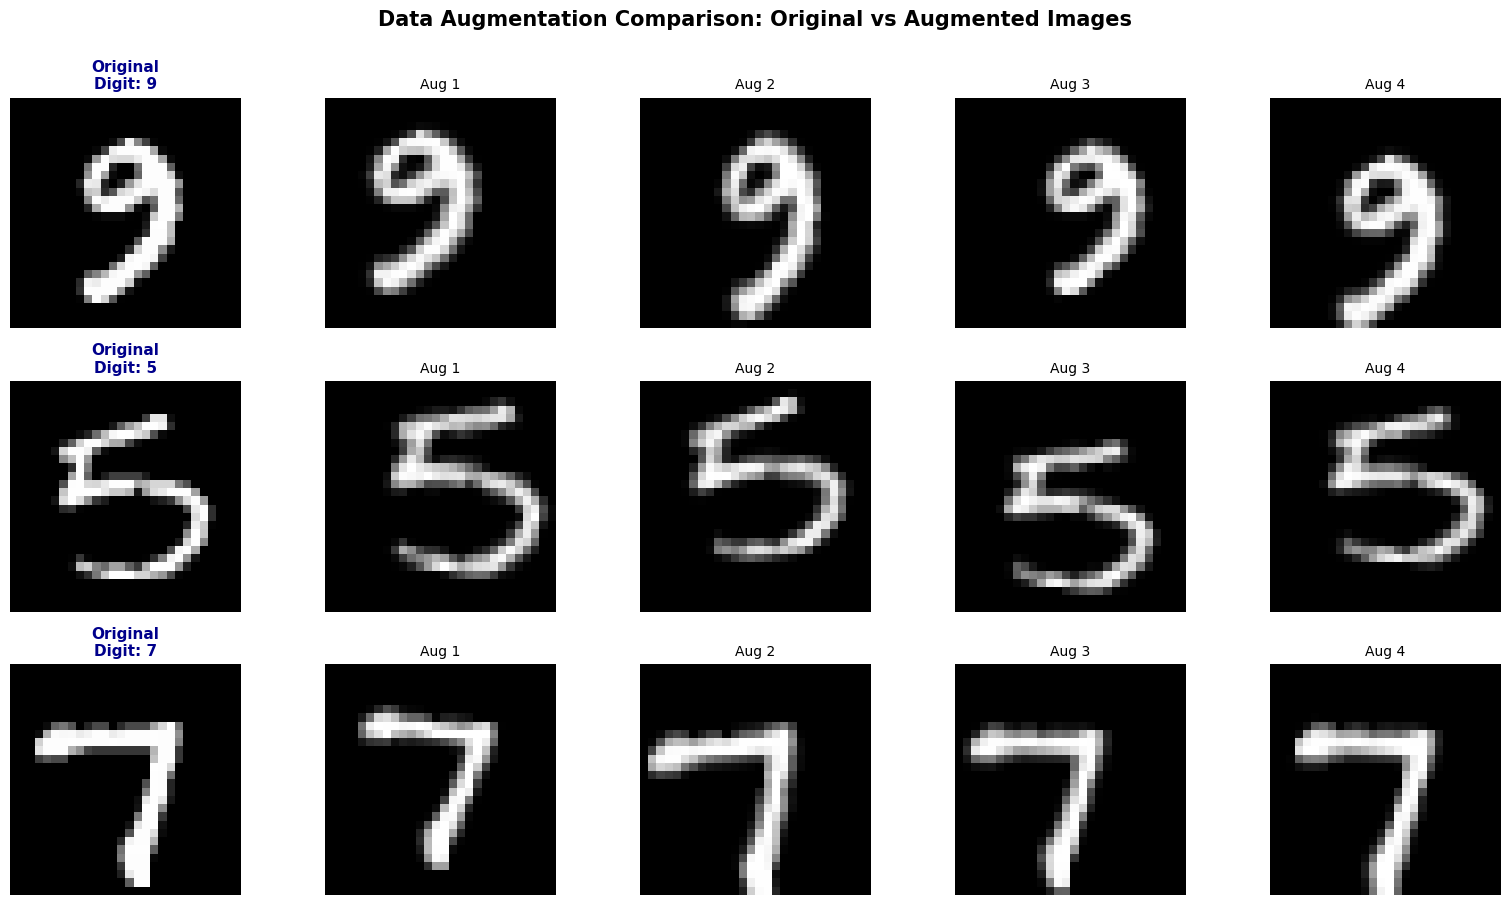

In [12]:
# --- Preview Augmented Data ---
num_samples = 3
num_augmentations = 4

fig, axes = plt.subplots(num_samples, num_augmentations + 1, 
                         figsize=(16, 3 * num_samples))

# Pilih random samples dari berbagai digit
sample_indices = np.random.choice(len(x_train), num_samples, replace=False)

for row, idx in enumerate(sample_indices):
    # Kolom 1: Gambar Original
    axes[row, 0].imshow(x_train[idx].reshape(28, 28), cmap='gray')
    axes[row, 0].set_title(f'Original\nDigit: {y_train[idx]}', 
                           fontweight='bold', fontsize=11, color='darkblue')
    axes[row, 0].axis('off')
    
    # Tambahkan border pada gambar original
    for spine in axes[row, 0].spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('darkblue')
        spine.set_linewidth(2)
    
    # Kolom 2-5: Augmented versions
    sample_image = x_train[idx].reshape(1, 28, 28, 1)
    aug_iter = datagen.flow(sample_image, batch_size=1)
    
    for col in range(1, num_augmentations + 1):
        augmented_image = next(aug_iter)[0]
        axes[row, col].imshow(augmented_image.reshape(28, 28), cmap='gray')
        axes[row, col].set_title(f'Aug {col}', fontsize=10)
        axes[row, col].axis('off')

plt.suptitle('Data Augmentation Comparison: Original vs Augmented Images', 
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [35]:
# --- Build CNN Model ---
model = keras.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, kernel_size=3, activation='relu', padding='same', input_shape=(28, 28, 1)),

    # Convolutional Layer 2
    layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    
    # Convolutional Layer 3
    layers.Conv2D(32, kernel_size=5, strides=2, padding='same', activation='relu'),
    layers.Dropout(0.3),
    
    # Convolutional Layer 4
    layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),

    # Convolutional Layer 5
    layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=2),  # Hanya 1 pooling lagi
    layers.Dropout(0.4),
    
    # Layer 6
    layers.Conv2D(128, kernel_size=3, activation='relu', padding='same'),
    
    # Fully-Connected Layer
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary model
model.summary()

/Users/nashwalaisya/supreme/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_39 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 14, 14, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 968,714 (3.70 MB)

 Trainable params: 968,714 (3.70 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# --- Training ---

# Decrease Learning Rate Each Epoch
annealer = LearningRateScheduler(lambda x: 1e-3 * 0.95 ** x)

# Callback untuk early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Training
history = model.fit(
    x_train, y_train_cat,
    batch_size=64,
    epochs=45,
    validation_split=0.1,
    callbacks=[early_stop, annealer],
    verbose=1
)

Epoch 1/45
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.9184 - loss: 0.2604 - val_accuracy: 0.9880 - val_loss: 0.0374 - learning_rate: 0.0010
Epoch 2/45
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.9743 - loss: 0.0898 - val_accuracy: 0.9898 - val_loss: 0.0336 - learning_rate: 9.5000e-04
Epoch 3/45
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.9819 - loss: 0.0635 - val_accuracy: 0.9907 - val_loss: 0.0317 - learning_rate: 9.0250e-04
Epoch 4/45
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.9848 - loss: 0.0529 - val_accuracy: 0.9923 - val_loss: 0.0280 - learning_rate: 8.5737e-04
Epoch 5/45
844/844 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - accuracy: 0.9864 - loss: 0.0463 - val_accuracy: 0.9928 - val_loss: 0.0260 - learning_rate: 8.1451e-04
Epoch 6/45
844/844 ━━━━━━━━━━━━━━━━━━━━ 50s 59ms/step - accuracy: 0.9892 - loss: 0.0368 - val_accuracy: 0.9935 - val_loss: 0.0242 - learning_rate: 7.7378e-04
Epoch 7/45
844/844 ━━━━━━━━━━━━━━━━━━━━ 49s 58ms/step - 


Test Loss: 0.0145
Test Accuracy: 0.9954 (99.54%)


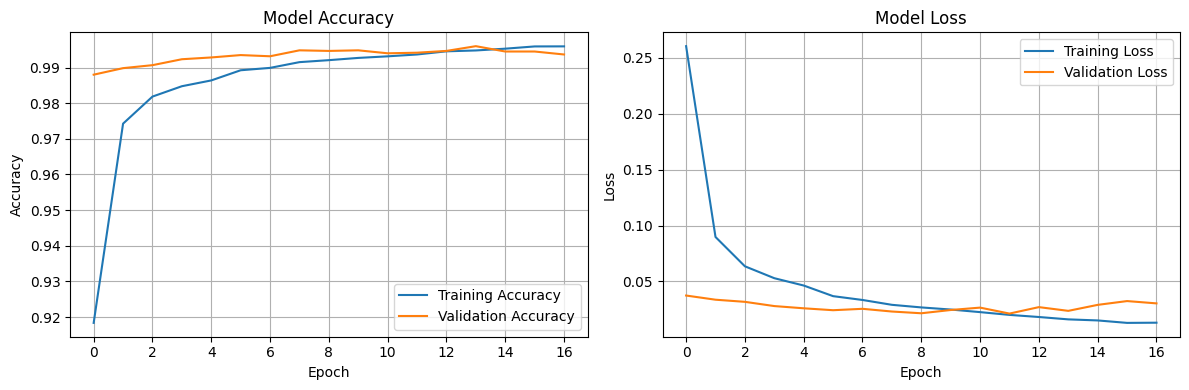

In [37]:
# --- Evaluasi ---
# Evaluasi pada test set
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Plot history training
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot loss
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


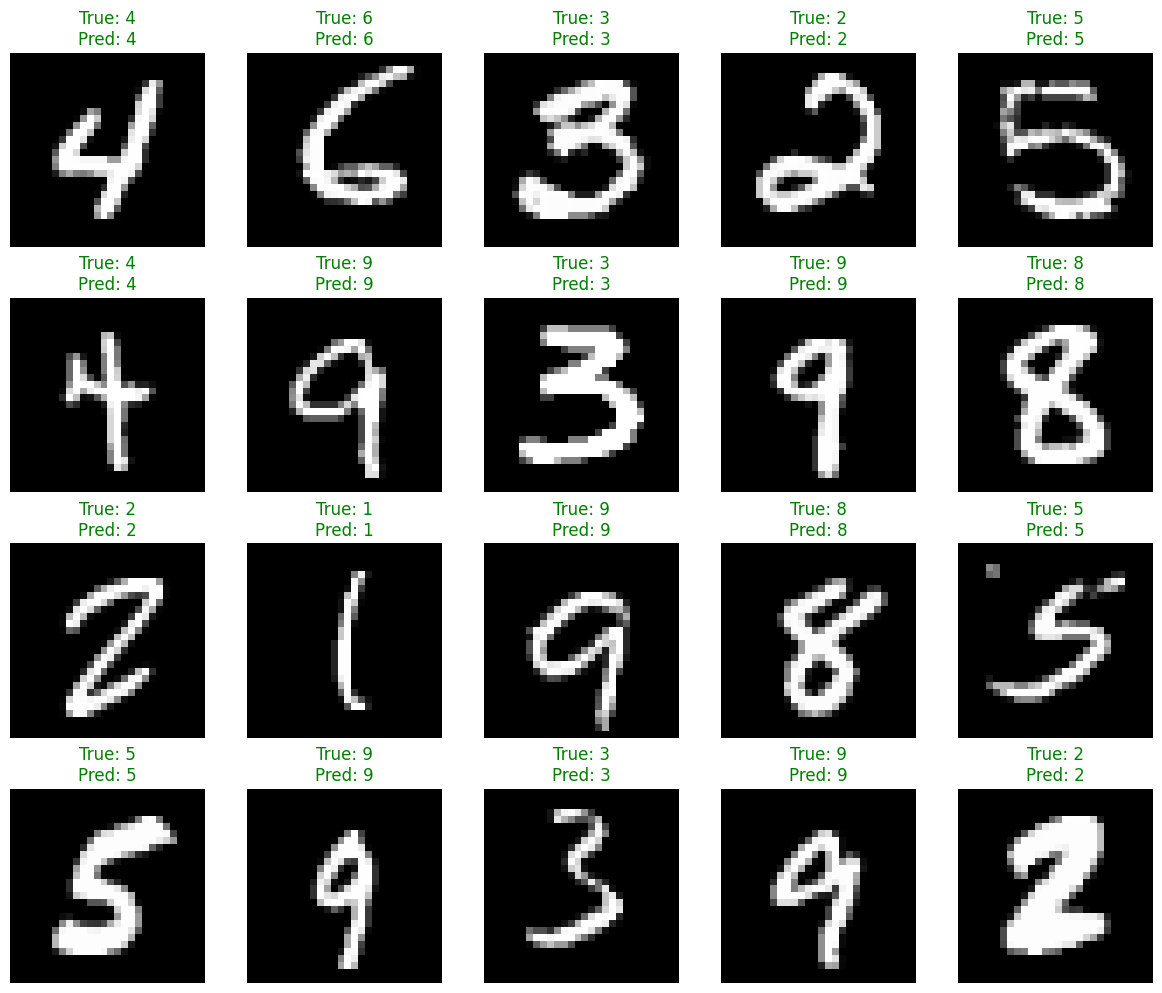

In [38]:
# --- Prediksi dan Visualisasi ---
# Prediksi
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Visualisasi prediksi
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
axes = axes.ravel()

# Pilih 20 sample random
indices = np.random.choice(len(x_test), 20, replace=False)

for i, idx in enumerate(indices):
    axes[i].imshow(x_test[idx].reshape(28, 28), cmap='gray')
    pred_label = y_pred_classes[idx]
    true_label = y_test[idx]
    
    # Warna hijau jika benar, merah jika salah
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
    axes[i].axis('off')

plt.tight_layout()


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       0.99      1.00      1.00      1010
           4       0.99      1.00      0.99       982
           5       0.99      1.00      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       0.99      1.00      1.00       974
           9       1.00      0.99      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



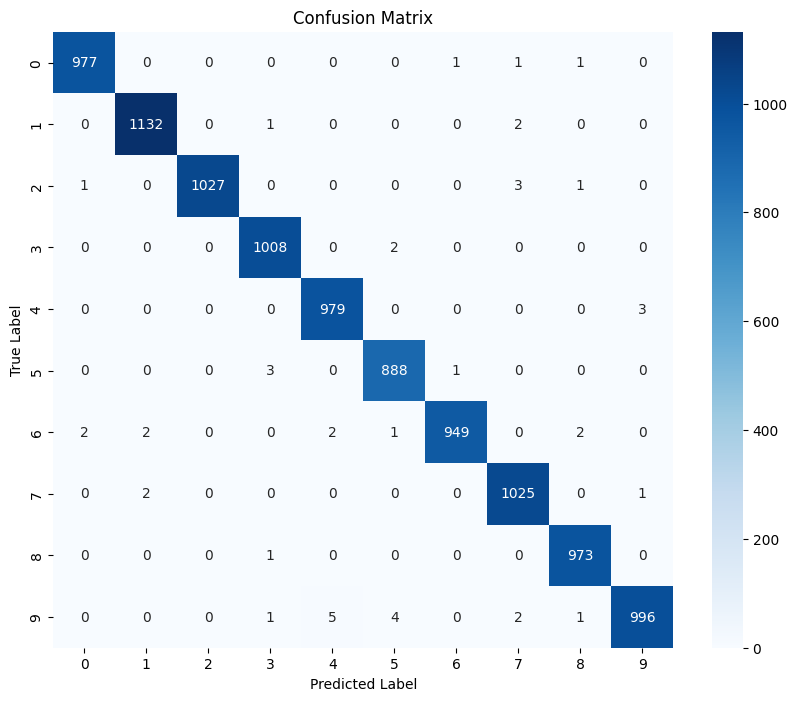

In [39]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))

In [ ]:
# --- Save Model ---
model.save('mnist_cnn_model.h5')
print("Model saved as 'mnist_cnn_model.h5'")

# Save as Keras format
model.save('mnist_cnn_model.keras')
print("Model saved as 'mnist_cnn_model.keras'")

print("\n" + "-"*50)
print("MNIST Digit Recognition - COMPLETED!")
print("="*50)
print(f"\nFinal Test Accuracy: {test_accuracy*100:.2f}%")

Model saved as 'mnist_cnn_model.h5'
Model saved as 'mnist_cnn_model.keras'

--------------------------------------------------
MNIST Digit Recognition - COMPLETED!

Final Test Accuracy: 99.54%

Model location:
/Users/nashwalaisya/Documents/Semester - 7/Machine Learning/tugas-besar/mnist_cnn_model.h5
/Users/nashwalaisya/Documents/Semester - 7/Machine Learning/tugas-besar/mnist_cnn_model.keras
